03 课程里我们主要按照[Bengio et al. 2003](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf) 这篇论文里的内容，实现了一个字母级别的MLP

我们跟随论文里的步骤，选取已有的一些字母，然后使用MLP去预测序列里的下一个字母

在后续课程安排里，我们希望更进一步，转向使用更加复杂、更加巨大的神经网络，例如 循环神经网络RNN(recurrent neural networks) 以及它们的变体诸如 GRU(Gated Recurrent Unit)和LSTM(Long Short-Term Memory)

在开始之前，我们仍然需要重点关注MLP角度，我们希望能够更加透彻的了解像是 训练时神经网络里的激活值、反向传播过程中的梯度 这些数据的表现。因为这对于了解这些神经网络结构的历史发展而言非常重要。例如，RNN 具有很强的表达能力，它是通用的万能逼近器，原则上可以执行任何算法。然而我们发现，使用我们已经学过的一阶基于梯度的优化技术来训练它们并不太方便。同时想要知道它们不容易优化的关键就在于去理解 激活值和梯度在训练过程中的具体表现。

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])        #80%
Xdev, Ydev = build_dataset(words[n1:n2])    #10%
Xte, Yte = build_dataset(words[n2:])        #10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited
n_embd = 10         # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 200      # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g) # character embedding table, 字符嵌入表
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                      generator=g)
W2 = torch.randn((n_hidden, vocab_size),        generator=g)
b2 = torch.randn(vocab_size,                    generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True  

11897


In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors, 将字符嵌入到向量中
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors, 将向量连接起来
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation, 隐藏层的预激活
    h = torch.tanh(hpreact) # hidden layer activation, 隐藏层的激活
    logits = h @ W2 + b2 # output layer pre-activation, 输出层的预激活
    loss = F.cross_entropy(logits, Yb) # loss function, 损失函数

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay, 学习率衰减
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/200000: 27.8817
  10000/200000: 2.9356
  20000/200000: 2.5331
  30000/200000: 2.9308
  40000/200000: 2.1004
  50000/200000: 2.4989
  60000/200000: 2.4067
  70000/200000: 2.1295
  80000/200000: 2.3477
  90000/200000: 2.3098
 100000/200000: 2.0809
 110000/200000: 2.3818
 120000/200000: 2.0194
 130000/200000: 2.4772
 140000/200000: 2.2544
 150000/200000: 2.1509
 160000/200000: 2.0979
 170000/200000: 1.8214
 180000/200000: 1.9808
 190000/200000: 1.8395


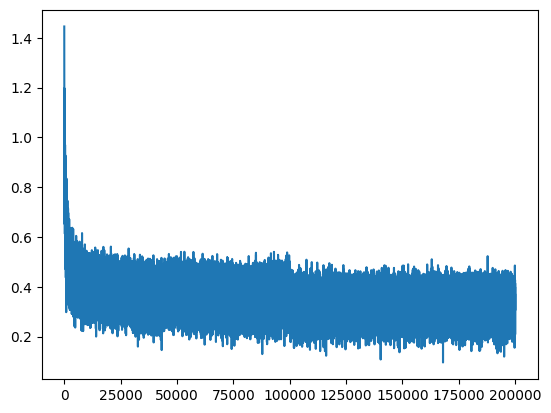

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad()    # this decorator tells PyTorch not to compute gradients, which we don't need for evaluation

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # (N, block_size*n_embd)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.1265742778778076
val 2.170107841491699
test 2.162759304046631


In [10]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):

    out = []
    context = [0] * block_size # initial context, 初始上下文

    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]    # (1, block_size, n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sampled the special end '.' token, break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

dexze.
moallusailah.
tyhamrinishana.
nella.
kama.
aristaivaulytharminton.
moriella.
kinz.
teda.
kaley.
maside.
enkavion.
roslyn.
hani.
gavtarlyn.
kashra.
anell.
pynn.
isa.
jana.


尽管现在的结果相较于之前的bigram而言，得到了很大进步，但实际上我们还有挺多的不足之处

首先就是在初始化阶段，我们的神经网络的各项参数都有错误

首先是在第0轮，我们可以看到 loss 是27.8817，尽管后面的loss都有所下降至2左右，但初始的27毕竟还是太大了

实际上在每次训练之前，我们都应该对loss有个大概的估算，比如说在什么区间

在这个例子里，我们需要训练的是 27 个字符(26字母+ .)的输出，由于在一开始我们并不能确定下一个字符的输出是什么，因此我们应该假定它们是均匀分布，每个都是 1/27 的概率，这才是我们初始化应该做的，给27个字符均等的概率，都是 1/27，进而对于loss而言，它的值应该是

In [11]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

所以一开始我们预测的loss应该是3.29，而不是远远大于的27.88

我们之所以在第0轮里算出 loss 是  27.88，是因为神经网络在一开始初始化创建概率的分布时并不是平均分配的，而是随机生成的，并且一开始生成的概率分布是非常不对的，这才导致 loss 非常的大

In [12]:
# MLP revisited
n_embd = 10         # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 200      # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g) # character embedding table, 字符嵌入表
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                      generator=g)
W2 = torch.randn((n_hidden, vocab_size),        generator=g)
b2 = torch.randn(vocab_size,                    generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True  

11897


In [13]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors, 将字符嵌入到向量中
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors, 将向量连接起来
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation, 隐藏层的预激活
    h = torch.tanh(hpreact) # hidden layer activation, 隐藏层的激活
    logits = h @ W2 + b2 # output layer pre-activation, 输出层的预激活
    loss = F.cross_entropy(logits, Yb) # loss function, 损失函数

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay, 学习率衰减
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    break


      0/200000: 27.8817


In [14]:
logits[0]

tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
          1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
         -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
         14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
       grad_fn=<SelectBackward0>)

在这里就能看到我们初始化时 logits 的值是非常极端的，所以导致 loss 变得非常非常高

下面来修正，如何正确的初始化

首先是因为
```python
logits = h @ W2 + b2
```
一开始，我们希望 logits 是0，所以不需要加上一个 bias，于是我们可以让 b2 为 0

所以给初始化时 乘上 0
```python
b2 = torch.randn(vocab_size,                    generator=g) * 0
```

此外，由于 logits 是 h 和 W2 的点积，我们希望 logits 尽可能小，所以也希望 W2 尽可能小，于是我们可以给 W2 也乘上个缩小系数
```python
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
```


In [15]:
# MLP revisited
n_embd = 10         # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 200      # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g) # character embedding table, 字符嵌入表
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                      generator=g)
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True  

11897


In [16]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors, 将字符嵌入到向量中
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors, 将向量连接起来
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation, 隐藏层的预激活
    h = torch.tanh(hpreact) # hidden layer activation, 隐藏层的激活
    logits = h @ W2 + b2 # output layer pre-activation, 输出层的预激活
    loss = F.cross_entropy(logits, Yb) # loss function, 损失函数

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay, 学习率衰减
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    break


      0/200000: 3.3221


再次运行，可以看到一开始的 loss 大概在 3.32 左右，明显优于之前的 27 ，已经很接近平均分配时的 3.29 了

这里也许有人会说不要那么麻烦把 W2 设置成小数，直接把 0.01 换成 0 ，把初始化 logits设为 0 不就得了

首先，如果把初始 logits 设为 0，优化过程会先把这些 logits 压扁（squashing down），然后再重新分配（rearranging），所以这样基本上就把损失函数中“缩小权重”那部分简单的收益给拿掉了。因此，在优化初期我们得不到那些简单的收获，而只能面对更困难的优化目标。所以我们的损失图像并不会像 hockey stick 那样。

其次，由于我们把损失函数中“缩小权重”那部分简单的收益给拿掉了(也就是常规 loss 图像里一开始的曲棍球杆形下降的部分)，我们的神经网络可以花更多的轮次在后面的优化上，所以最后的结果可能比较好

这样一看确实似乎直接设置为 0 比较好，但实际上还是会有一些更深层的问题出现

我们可以看一下目前神经网络里 h 和 hpreact 的分布情况

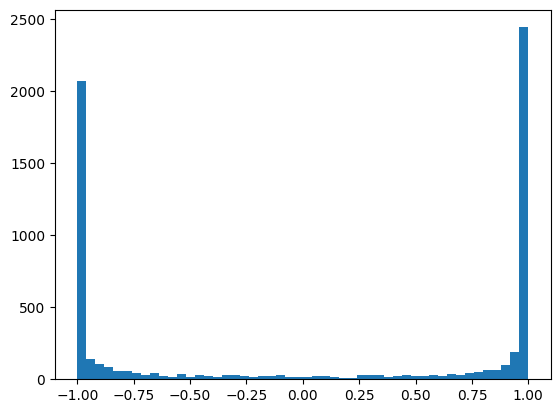

In [17]:
plt.hist(h.view(-1).tolist(), 50);

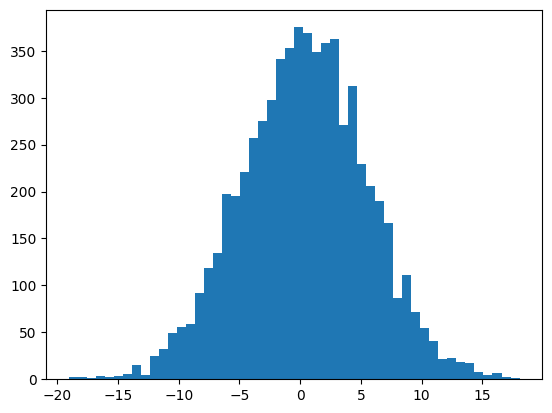

In [18]:
plt.hist(hpreact.view(-1).tolist(), 50);

可以看到对于 h 来说，有许多极端的 正负1 极值；对于 hpreact 来说，它的分布也是非常广阔的，在-15到15之间，这也是为什么在 tanh 里面这些值会被变化成 正负1

对于初学者来说，这可能并不是一个值得关注的问题。但是深入了解之后，尤其是从梯度的反向传播角度去观察，就能看到问题所在。

比如说对于 tanh 函数，如果它的值是极端的正负 1 ，那么在梯度的传播过程中，这一块的梯度几乎就会变为0，所以这个 tanh 神经元包含的 权重(weight) 偏置(bias) 对最后的 loss 来说几乎没有什么作用。在这个例子里，由于 h 有很多正负 1 的极值，那么梯度在反向传播的过程中到达这一层时就会被摧毁(由链式法则可知传递的梯度为 这一层的梯度(0) 乘上 之前传过来的梯度)

对于某一个神经元，如果它的所有值都在 tanh 的平坦层(也即是说都是正负 1 极值)，那么这个神经元什么也不会学习到，它就是一个 dead neuron

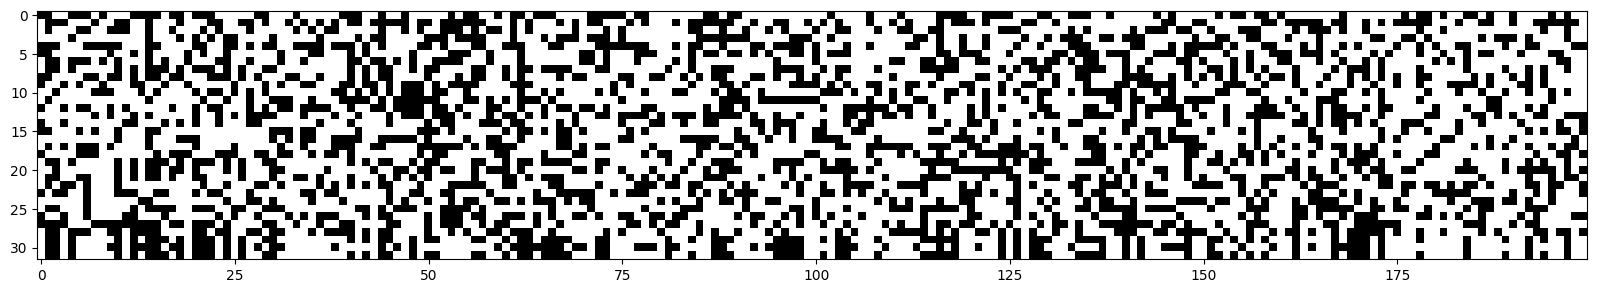

In [19]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest');

从上面的图可以看到，如果 h.abs()>0.99 它就会是白色的，这个图是32*200，每一行代表着一条输入，每一列代表着一个神经元

如果有一列是完全是白色的，就说明它是一个没有起作用的 dead neuron

具体的在这个例子里，一个 tanh 的neuron，如果它是一个 dead neuron，那么对于任何的输入，它都只会输出 正负1，也就是说梯度在这里就摧毁了，进而它学不到任何东西

那么如何来解决这个问题？我们知道梯度被摧毁的原因是由于 tanh 的值都是极端的正负1，而tanh的输入来自于 hpreact 。由上面的图可以看到这是因为 hpreact 的数值在 -15 到 15 区间，这个范围太大了，导致经过 tanh 激活后有很多极端值。而 hpreact = embcat @ W1 + b1 这里的 embcat 来自于C[X] ，这个是正态分布的，但是它会和 W1 点积，并且加上偏置 b1，这就导致 hpreact 的值远远离开 0 附近。

所以解决的方法也很简单，首先和 logits 那边类似，给bias设置的也很小(不设置为0，是因为希望引入一点点 entropy)，比如说乘上系数 0.01 ，同时对于权重 W1 ，我们也可以类似的乘上系数 0.1 

In [20]:
# MLP revisited
n_embd = 10         # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 200      # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g) # character embedding table, 字符嵌入表
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * 0.1
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True  

11897


In [21]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors, 将字符嵌入到向量中
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors, 将向量连接起来
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation, 隐藏层的预激活
    h = torch.tanh(hpreact) # hidden layer activation, 隐藏层的激活
    logits = h @ W2 + b2 # output layer pre-activation, 输出层的预激活
    loss = F.cross_entropy(logits, Yb) # loss function, 损失函数

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay, 学习率衰减
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    break


      0/200000: 3.3069


再来观察一下 h 和 hpreact 的分布情况

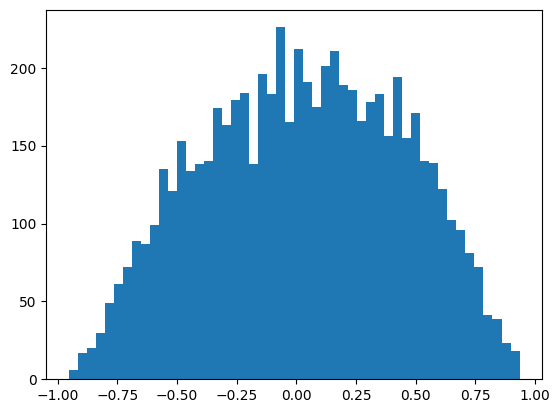

In [22]:
plt.hist(h.view(-1).tolist(), 50);

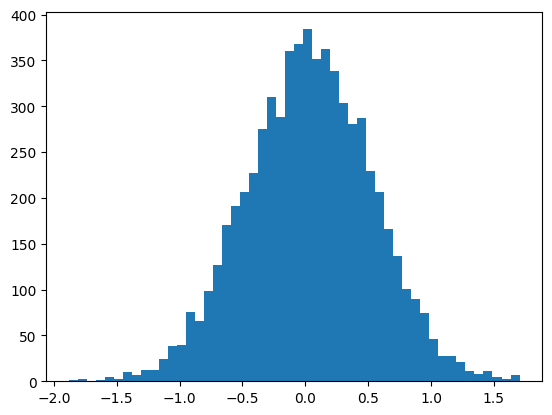

In [23]:
plt.hist(hpreact.view(-1).tolist(), 50);

可以看到情况明显得到改善，这是因为 hpreact 的值的范围都在 [-1.5,1.5] 之间。再来看看死神经元的情况，可以看到白色的全部都消失了，说明每个神经元都有梯度，都能学习到内容

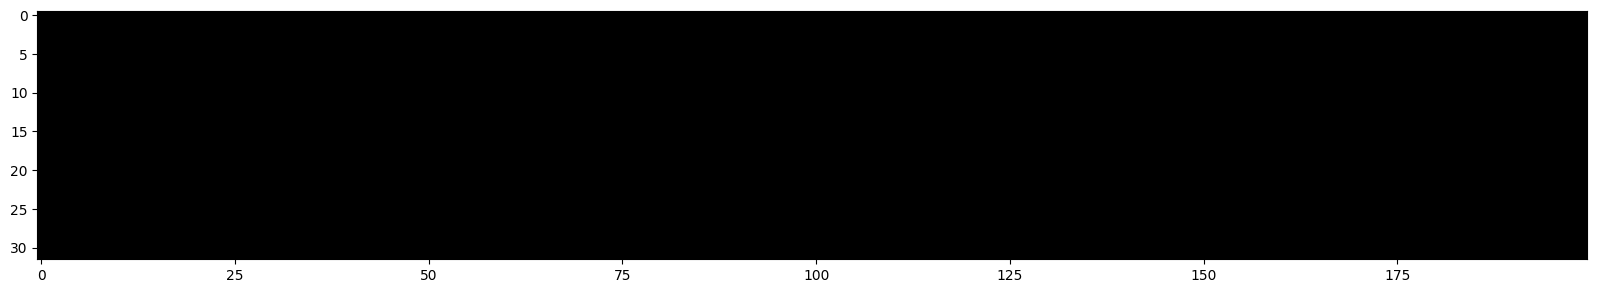

In [24]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest');

我们可以比较一下改进前后的 loss 训练情况
这里我没有举例自己的数据，给出的是 karpathy 笔记里的数据

```python
# original:
train 2.124
val 2.168

# fix softmax confidently wrong:
train 2.07
val 2.13

# fix tanh layer too saturated at init:
train 2.035
val 2.1026
```

可以看出经过初始化时的一些参数设置改进，我们的训练效果得到了一定程度上的提升

主要原因如下： 首先是在输出概率这部分，修正 softmax 高置信度错误，使得初始的logits平均接近于0，这样避免了一开始的loss过大，减少了一开始的权重快速下降阶段，同时可以给出更多的轮次来训练后面的loss部分；其次是在 tanh 层，我们修复了初始化时饱和度过高的问题，解决了因为极值导致梯度消失、参数更新缓慢的弊端

由于这个例子只是一个简单的神经网络，只有一层，所以优化起来非常简洁，需要解决的问题也比较简单，甚至有时候不解决这些问题同样也能得到不错的答案。

但这并不表明这是对的，一旦我们开始进行更深更大的神经网络训练时，问题会变得更加复杂，如果初始化不注意的化，最后导致的结果可能就是压根就没法训练，所以这些错误都需要注意。

同时，虽然我们解决了上述的问题，但是采用的方法里像 0.1 0.01 这些数字都是magic number， 那么遇到更加复杂、层数更多的网络时又该如何选择呢？

事实上，我们有一些相关的原则可以参考来设置这些参数

tensor(-0.0036) tensor(1.0000)
tensor(0.0096) tensor(3.1525)


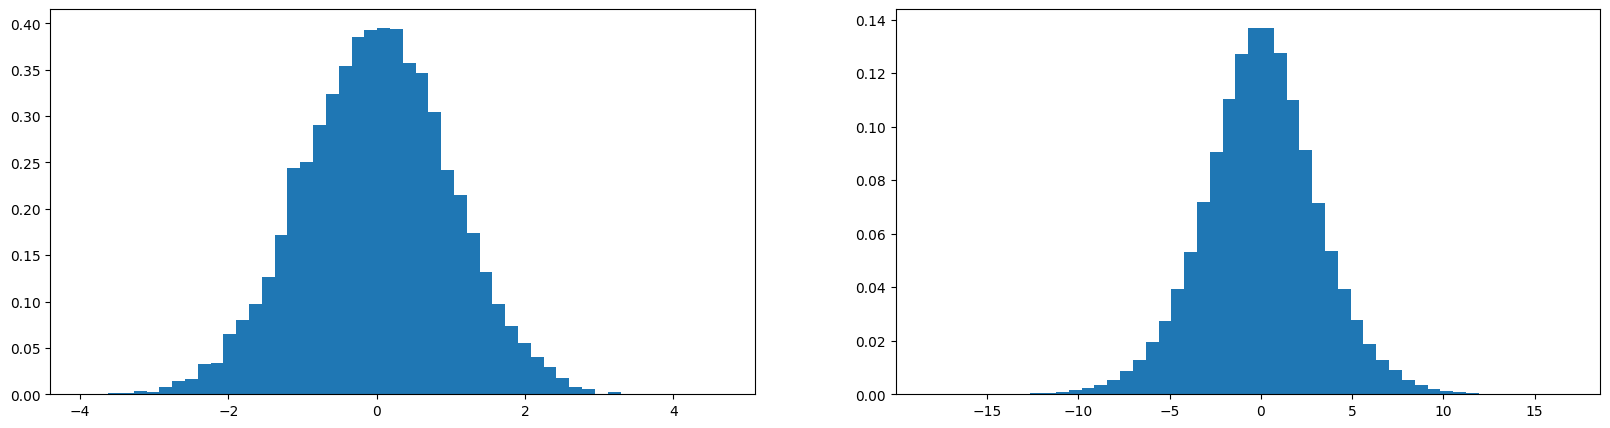

In [25]:
x = torch.randn(1000,10)    # 1000个样本，每个样本10维，通过正态分布随机生成输入数据
w = torch.randn(10,200)     # 10维输入，200个隐藏层神经元，通过正态分布随机生成权重矩阵

y = x @ w    # (1000,200) = (1000,10) @ (10,200)
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50,density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50,density=True);

从上面的图可以看到，由于使用正态分布初始化，所以一开始 x 的分布看起来比较正常，但是在和 w 点积之后得到 y ，可以看到 y 的样本分布幅度拓展了

虽然 x 和 y 的平均值都接近 0 (正态分布的性质)，但是可以看到 标准差(std) y明显大于 x，这就表明 y 的分布跨度更大，这并不是我们想要的，我们希望的是神经网络的大部分的激活值都是相似的(不想要太多的极值)

所以实际上我们可以在 w 上乘以一个系数，来使得这个点积的结果更加的收敛一点(比如说让std 在1左右)，那么问题就转变成我们到底需要乘以多大的系数来阻止这个分布的扩展，从而保证标准差在 1 附近

从数学角度给出的解释是，从数学上解释，需要将权重 w 除以它的 fan‑in 的平方根(乘上n分之一的平方根)。(比如说w = torch.randn(10,200)，那就要除以根号10)

tensor(-0.0187) tensor(0.9978)
tensor(0.0005) tensor(0.9906)


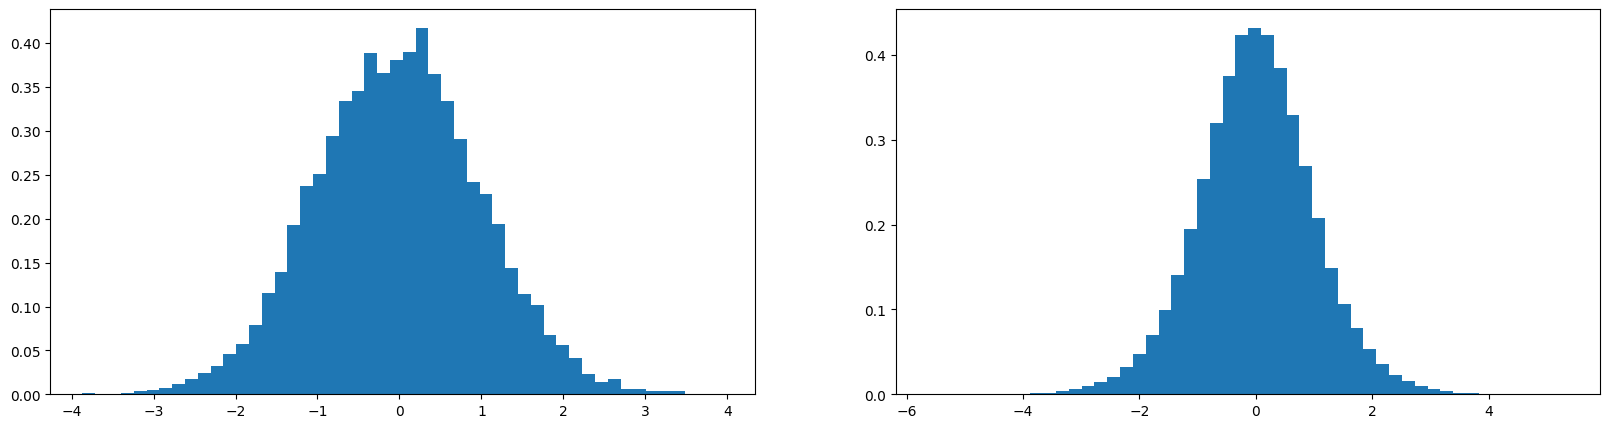

In [26]:
x = torch.randn(1000,10)    # 1000个样本，每个样本10维，通过正态分布随机生成输入数据
w = torch.randn(10,200) / 10**0.5    # 10维输入，200个隐藏层神经元，通过正态分布随机生成权重矩阵

y = x @ w    # (1000,200) = (1000,10) @ (10,200)
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50,density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50,density=True);

可以看到，经过除以系数处理后，图像分布情况得到了明显改善。

实际上，许多研究都关注如何对神经网络进行最优初始化。在多层感知机(MLP)领域中，我们经常会遇到非常深的非线性网络层。为了使这些激活函数表现良好，既不趋于无穷大也不衰减到零，我们需要关注权重的初始化方式，以确保激活值处于合理的范围内。例如，何恺明等人的论文《Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification》就是该领域中被广泛引用的经典工作。

在这篇论文里，他们主要研究了卷积神经网络(CNN)，并重点关注了 ReLU  和 PReLU 两种非线性激活函数，而不是我们例子里的 tanh 非线性激活函数，但是这些分析都是非常类似的

以 ReLU 为例，它本质上是一个挤压函数（squashing function）：所有负值都被映射为 0，正数则原样通过。这就意味着大约一半的分布（正态分布中正负各占一半）被丢弃了。因此，研究者发现，在神经网络的正向传播过程中必须给予一定的补偿，例如采用均值为 0、标准差为n分之二的平方根的正态分布(而在我们上面的例子里，我们是用n分之一的平方根)

该论文不仅研究了正向传播，还关注了反向传播，目的是确保梯度的行为同样良好。研究发现，如果正向传播部分的权重初始化得当，那么反向传播通常也能获得较好的初始化，二者之间仅相差一个常数因子。这个常数因子与前一层和后一层隐藏层的神经元数量有关，但总体而言并不是特别关键。

事实上，在pytorch里，就有 torch.nn.init.kaiming_normal_(tensor, a = 0, mode ='fan_in', nonlinearity='leaky_relu')

这里 mode 用于选择正向传播还是反向传播，由于前面提到反向传播的影响不大，所以一般就是 default fin_in(反向是 fan_out)

另一个是非线性激活函数的选择，前面提到在原论文里需要添加一个补偿，这个补偿的具体内容就是标准差，其值为 gain/根号n , 不同的函数有着不同的gain，比如说ReLU就是根号2，Linear/Identity是1，tanh的建议值是三分之五(我们上面选择的是1，和建议值有出入但问题不大) 等等

这篇论文强调，在初始化深度神经网络时必须非常小心，尤其是当网络非常深时，这些细节十分敏感且容易出问题。但好在现代有许多创新方法使得神经网络变得更加稳定、表现更加良好，因此初始化的重要性已不像过去那样突出。这些创新方法包括：残差连接（Residual Connections）、各种标准化层的引入（如批量归一化、层归一化、分组归一化），以及更先进的优化器（不再局限于随机梯度下降，还包括 RMSprop、Adam 等复杂优化器）。正是这些现代创新技术的加入，使得神经网络的初始化不再需要过分精细的调参。

Karpathy 在课程中提到，他在实际应用中初始化神经网络时，也只是简单地将权重除以输入维度的平方根


下面我们就开始介绍一下上面提到的现代创新技术



我们首先先来看一下 batch normalization

batch normalization 是谷歌的一个团队在2015年提出的，这篇论文有着非常大的影响，因为它使得可靠的训练非常深的神经网络变成可能

In [27]:
hpreact = embcat @ W1 + b1 # hidden layer pre-activation, 隐藏层的预激活

# 这里我们希望输入到 tanh 的 hpreact 的分布在 -1 到 1 之间，也就是标准的正态分布
# 这样的话 tanh 的输出 h 就不会饱和在 -1 或 1 上，而是会有更多的梯度流动，帮助模型学习
# 前面我们通过给权重矩阵 W1 乘以 0.1 来缩小了 hpreact 的值
# 但是在 batch normalization 里，我们可以之间对 hpreact 进行标准化，使其具有零均值和单位方差，这样就不需要手动调整权重的初始值了

hpreact = (hpreact - hpreact.mean(0, keepdim = True)) / hpreact.std(0, keepdim = True) # batch normalization, 批量归一化

h = torch.tanh(hpreact) # hidden layer activation, 隐藏层的激活

对于形状为 [32, 200] 的 hpreact，沿着 batch 维度（第0维）计算均值和标准差，得到形状 [1, 200] 的统计量。然后用这些统计量对每个样本（共32个）进行归一化：(hpreact - mean) / std，输出形状仍是 [32, 200]。这样一来，每个归一化后的样本都融合了当前 batch 中所有32个样本的统计信息，不过每个样本仍然是独立的个体

但是这样的话，我们在每一轮训练中都会强制的给 hpreact 限制为正态分布，在梯度的反向传播过程中，也会收到限制，大大削弱了神经网络的多样学习的效果，所以除了了这个方法以外，我们还需要介绍一下论文里提到的另一个方法: scale and shift。 这个具体的作用就是我们使用一些 gain 来scale刚才归一化的数据，同时用bias来offsetting 他们，类似做了一种 y= ax + b的变换，来得到我们的最终输入 y

In [28]:
# MLP revisited
n_embd = 10         # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 200      # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g) # character embedding table, 字符嵌入表
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * 0.1
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

bngain = torch.ones((1, n_hidden))            # 设置gain 来scale刚才归一化的数据
bnbias = torch.zeros((1, n_hidden))           # 设置bias 来shift刚才归一化的数据, 同时要添加到下面的parameters列表中，这样它们的梯度也会被计算和更新

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True  

12297


In [29]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors, 将字符嵌入到向量中
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors, 将向量连接起来
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation, 隐藏层的预激活

    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim = True)) / hpreact.std(0, keepdim = True) + bnbias # batch normalization, 批量归一化

    h = torch.tanh(hpreact) # hidden layer activation, 隐藏层的激活
    logits = h @ W2 + b2 # output layer pre-activation, 输出层的预激活
    loss = F.cross_entropy(logits, Yb) # loss function, 损失函数

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay, 学习率衰减
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    break


      0/200000: 3.3147


首先由于(hpreact - hpreact.mean(0, keepdim = True)) / hpreact.std(0, keepdim = True)这一步已经把它变成接近标准的mean=0，std=1的正态分布，然后我们乘上torch.ones((1, n_hidden))的bngain和torch.zeros((1, n_hidden)) 的bnbias，所以还是接近标准的正态分布

并且由于bngain和bnbias的存在，在梯度的反向传播过程中可以改变它们的值，所以不再会受到(hpreact - hpreact.mean(0, keepdim = True)) / hpreact.std(0, keepdim = True)这个步骤的强制归一化限制，使得神经网络得以全面的学习。

这里可以比较看一下前面的 何凯明初始化 以及 batch normalization 的效果，由于篇幅原因具体没有运行，这里展示karpathy笔记里的benchmark
```python
# original:
train 2.124538
val 2.1681964

# fix softmax confidently wrong:
train 2.07
val 2.13

# fix tanh layer too saturated at init:
train 2.0355966
val 2.1026

# using semi-principled "kaiming init" instead of hacky init:
train 2.037664
val 2.16819

# add a batch norm layer
train 2.066827
val 2.1048448
```
可以看到，这个batch norm的方法提升相较于其他的有限，这是因为例子里的神经网络比较简单，就只有一层，所以我们如果采用何凯明的方法，完全可以计算出具体的gain来修正，所以效果肯定比这个要好。但是如果拓展到更加复杂、更加深的神经网络，我们不可能计算出每一层每一个地方的gain，所以使用这个方法是可以大大优化我们的训练过程的。

但是这个方法也会带来一定的开销，在原本的每一个logits中，我们只需要考虑特定的这个输入就行，但是现在由于引入了归一化步骤，我们对于每一个，都需要计算一整个batch的数值

不过正是由于这个因素，所以对于每一个example输入，它具体的h激活时会有轻微的不同，这取决于它所在的那个batch。这点扰动是BN在训练时引入的隐式正则化：同一个样本在不同 batch 中得到的归一化结果略有不同，相当于在激活值上添加了微小的噪声，有类似于 Dropout 的正则化效果，可以减轻过拟合。

但这种依赖于 batch 的扰动有时并不符合人们的需求，因为结果过于依赖当前 batch 中的其他样本，这未必是期望的效果。因此，在某些情况下，人们会放弃使用 Batch Normalization，转而采用其他不将样本之间耦合在一起的方法，比如说layer normalization、instance normalization、group normalization。

此外还有一个事情需要提及，我们知道在训练过程中，我们使用了 batch normalization，这就意味着我们希望的输入是一个 batch，因为这样我们才能对这一组数据进行归一化操作。那么当我们训练完成之后，在实际应用时，我们输入一条数据来做预测，那么该怎么办呢？在原论文里采用的方法如下：我们会在训练步骤之后额外增加一个step，在这一部分我们将会 calibrate the batch norm，即训练结束后，冻结所有参数，将整个训练集再次通过模型，重新计算每个BN层在整个数据集上的均值和方差，以此替换训练中移动平均累积的统计量。推理时对单一样本直接使用这些校准后的全局统计量进行归一化。这样就可以单独的用一条数据来进行预测。

In [31]:
# calibrate the batch norm

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr] 
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1 
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim = True)
    bnstd = hpreact.std(0, keepdim = True)

In [32]:
@torch.no_grad()    # this decorator tells PyTorch not to compute gradients, which we don't need for evaluation

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.267961263656616
val 3.2674903869628906


但是显然，没有人会愿意在最后再单独的来计算这些数据，因为这太烦琐了。所以在原论文里又提供了一个方法，我们可以在训练的时候计算这些数据

In [35]:
# MLP revisited
n_embd = 10         # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 200      # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator=g) # character embedding table, 字符嵌入表
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * 0.1
b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),        generator=g) * 0.01
b2 = torch.randn(vocab_size,                    generator=g) * 0

bngain = torch.ones((1, n_hidden))            # 设置gain 来scale刚才归一化的数据
bnbias = torch.zeros((1, n_hidden))           # 设置bias 来shift刚才归一化的数据, 同时要添加到下面的parameters列表中，这样它们的梯度也会被计算和更新

bnmean_running = torch.zeros((1, n_hidden))    # 运行时的均值，初始为0
bnstd_running = torch.ones((1, n_hidden))      # 运行时的标准差，初始为1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True  

12297


In [36]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1 

    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi = hpreact.std(0, keepdim = True)

    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # 这里单独的把 bnmean 和 bnstd 统计出来

    with torch.no_grad():   # 在更新 running mean/std 时不需要计算梯度，节省开销
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Yb) 

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    break


      0/200000: 3.3147


这样在进行梯度下降的同时，bnmean_running 和 bnstd_running 也在逐步更新，最终得到的效果与 在训练完之后再单独计算的结果相差不大

因此在预测时就可以用 bnmean_running 和 bnstd_running 来计算

In [37]:
@torch.no_grad()    # this decorator tells PyTorch not to compute gradients, which we don't need for evaluation

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.2748091220855713
val 3.274754762649536


ok，batch normal 差不多就这些内容了，这里再额外稍微讲一下前面没有提到的两个注意点

第一点是在这里
```python
hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

# 在原论文里面，这里是建议再 bnstd 这里再加上一个小的 Epsilon
# 这是为了防止除 0 错误，因为有可能这个 batch 的 std 就是正好是 0
```


第二点是在这里
```python
    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 

    hpreact = embcat @ W1 + b1          ## 这一行

    bnmeani = hpreact.mean(0, keepdim = True)
    bnstdi = hpreact.std(0, keepdim = True)

    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # 这里单独的把 bnmean 和 bnstd 统计出来

# 我们这里给 hpreact 加上了偏置b1，但实际上没有任何作用，因为下面我们计算的是mean和std，会把b1给抵消掉，所以实际上 b1 的grad是0，根本没有起到作用
# 所以在使用 batch normalization 时，如果在前面有一个权重层，那最好可以把bias给注释掉，因为实际上起作用的是我们下面的 bnbias
# 一句话来说就是 batch normalization 有着自己的bias (bnbias)，它会来进行修正，所以原本的bias就是冗余了
```

最后来给 batch normalization 一个总结：

我们使用 bn 来控制神经网络的各项激活值，在神经网络里引入 bn 层是非常常见的。通常我们会在有乘法的层(比方说线性层或者卷积层)后面加上bn层。bn 内部也有像 gain 和 bias这样的参数，这些参数也是使用梯度反向传播来训练的。同时他也有两个buffers，分别是bnmean_running和bnstd_running,这两个是不需要通过梯度训练的，只是简单的更新。

batch normalization 方法 做的事情就是计算传入的一个batch里的mean和std，然后把这一个batch 归一化，变成unit Gaussian，并通过学习到的 gain 和 bias对其进行修正，与此同时还记录维护bnmean_running和bnstd_running，这些会在后续的推理中用上，这样我们就不需要在最后再去计算总的mean和std了。

这节课程的总结

首先，理解激活函数和梯度的行为表现，对于神经网络的训练至关重要，尤其是当网络变得很深、很大的时候。

我们一开始观察了输出层的激活分布，发现：如果上一层的激活值过于混乱，模型会出现两种“自信的错误预测”（confident mispredictions），导致损失曲线呈现出“曲棍球杆”形状（hockey stick）。一旦你修正了这个问题，损失就会明显改善，因为训练过程中不再做那些无用的努力。

同时我们也认识到，我们需要控制激活函数的数值范围。我们既不希望它们坍缩到 0，也不希望它们膨胀到无穷，而是希望在整个训练过程中，这些激活值保持相对均匀（fairly homogeneous），大致符合高斯分布。于是我们引入了何凯明论文中的初始化方法，对原始数值进行变换和修正，让它们尽可能接近正态分布。但我们也知道，这种方法并不具备普适性，尤其是当网络变得更复杂时，我们很难为每一层的权重和偏置都设置出合理的初始值。

顺理成章地，我们引入了归一化层的概念。在实践中，人们会使用多种归一化层，包括 Batch Normalization、Layer Normalization、Instance Normalization、Group Normalization 等。本课程重点介绍了 Batch Normalization。我们可以在神经网络的各个位置插入 BN 层，其基本思路是：既然我们希望激活函数前的输入大致服从高斯分布，那么我们就直接计算当前 batch 的均值和标准差，然后将这个 batch 归一化，使其变成单位高斯分布（unit Gaussian）。对于原本分布就已经比较好的数据，这个变换影响不大；但对于原本分布不佳的数据，这种变换可能会丢失信息。因此，我们再引入可学习的 gain 和 bias，对归一化后的高斯分布进行修正。

由于我们需要计算一个 batch 的均值和标准差，问题随之而来：推理阶段只有一条数据时该怎么办？一个直观的办法是在训练完成后，对所有训练数据重新计算全局均值和标准差，然后在推理时直接使用。但这样“事后诸葛亮”的做法过于繁琐。于是，我们引入了 bnmean_running 和 bnstd_running，在训练过程中通过移动平均同步记录这些统计量，推理时直接拿来用即可。

另外需要指出，Batch Normalization 对 batch 中的其他样本存在较强的耦合——归一化结果取决于当前 batch 中其他样本的取值。因此在某些情况下（例如 batch size 很小，或者需要处理变长序列时），人们会放弃使用 Batch Normalization，转而采用样本之间不耦合的方法，如 Group Normalization 等。

不过无论如何，在 BN 方法发布的 2015 年，它还是极具影响力的——它可以说是第一种能让你稳定训练深层神经网络的技术。最根本的原因在于，它在控制激活值的统计分布方面非常有效。




In [119]:
# summary plus

# Lets train a deeper network

class Linear:

    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.randn(fan_out, generator=g) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters(trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers(trained with a running 'momentum updata')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean=x.mean(0, keepdim=True)   # batch mean, 计算当前批次的均值
            xvar=x.var(0, keepdim=True)     # batch variance, 计算当前批次的方差
        else:
            xmean=self.running_mean
            xvar=self.running_var

        xhat=(x-xmean)/torch.sqrt(xvar+self.eps)    # normalize the batch, 对当前批次的数据进行标准化
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = self.momentum * xmean + (1-self.momentum) * self.running_mean
                self.running_var = self.momentum * xvar + (1-self.momentum) * self.running_var
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []


n_embd = 10     # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 100  # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),           generator=g)
layers = [ 
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident,
    layers[-1].gamma *= 0.1
    #layers[-1].weight *= 0.1
    # all the other layers: apply again
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))    # number of parameters in total, 总参数数量
for p in parameters:
    p.requires_grad = True

47551


In [120]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()   # retain intermediate outputs for backpropagation
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std()/p.data.std()).log10().item() for p in parameters])

    if i>1000:
        break

      0/200000: 3.3063


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.91%
layer 5 (      Tanh): mean -0.00, std 0.64, saturated: 2.75%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.72%
layer 11 (      Tanh): mean -0.01, std 0.65, saturated: 1.94%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.66%


Text(0.5, 1.0, 'activation distributions')

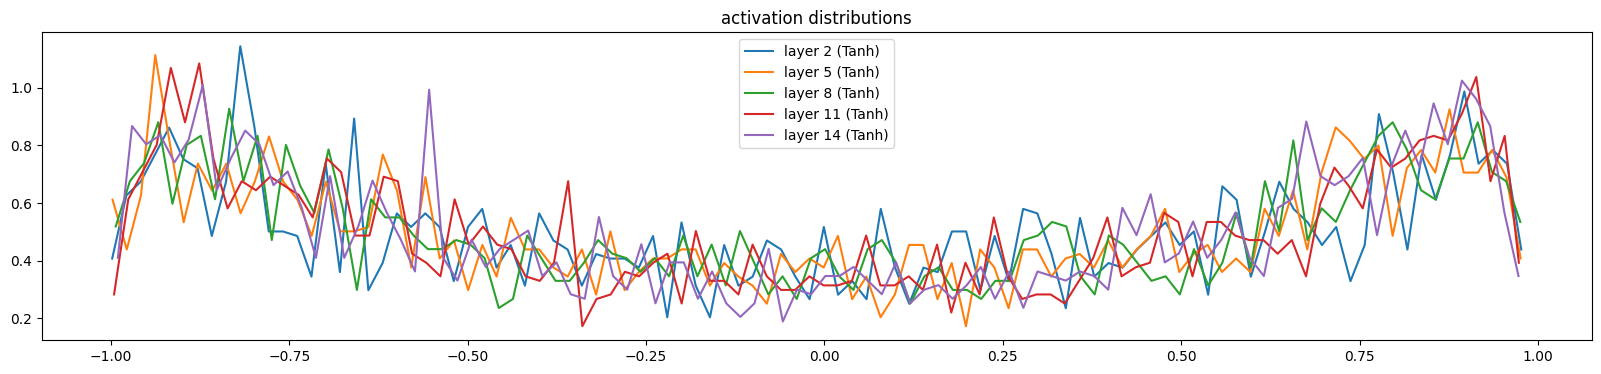

In [121]:
# visualize histograms
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):     # 不包括最后一层
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs()>0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distributions')

layer 2 (      Tanh): mean -0.000000, std 3.495707e-03
layer 5 (      Tanh): mean -0.000000, std 2.951499e-03
layer 8 (      Tanh): mean +0.000000, std 2.611985e-03
layer 11 (      Tanh): mean -0.000000, std 2.524609e-03
layer 14 (      Tanh): mean -0.000000, std 2.505544e-03


Text(0.5, 1.0, 'gradient distributions')

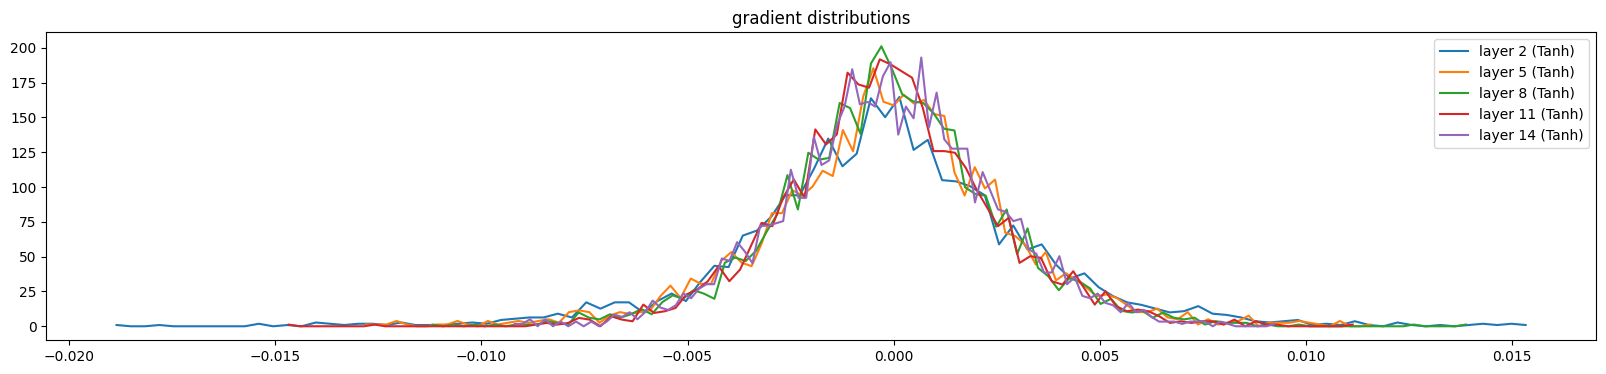

In [122]:
# visualize histograms
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):     # 不包括最后一层
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('gradient distributions')

weight   (27, 10) | mean +0.000000 | std 8.795530e-03 |grad:data ratio 8.786804e-03
weight  (30, 100) | mean +0.000113 | std 8.088293e-03 |grad:data ratio 2.587889e-02
weight (100, 100) | mean -0.000021 | std 7.160068e-03 |grad:data ratio 4.267826e-02
weight (100, 100) | mean +0.000089 | std 5.988696e-03 |grad:data ratio 3.604709e-02
weight (100, 100) | mean -0.000050 | std 5.043145e-03 |grad:data ratio 3.017228e-02
weight (100, 100) | mean +0.000019 | std 5.276986e-03 |grad:data ratio 3.148127e-02
weight  (100, 27) | mean +0.000167 | std 9.968234e-03 |grad:data ratio 5.957657e-02


Text(0.5, 1.0, 'weights gradient distributions')

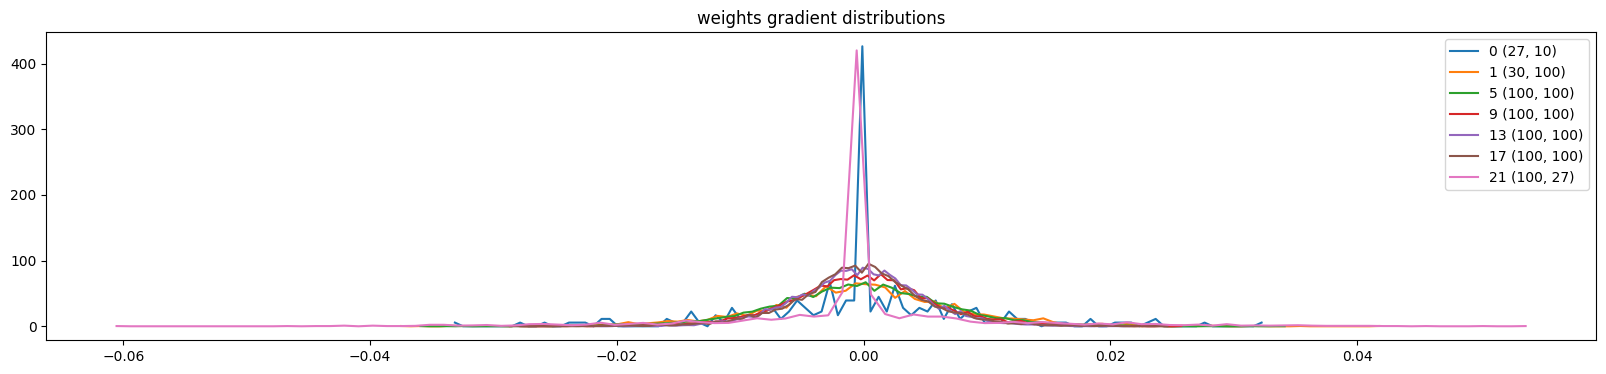

In [123]:
# visualize histograms
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):     # 包括所有参数
        t = p.grad
        if p.ndim == 2:
            print('weight %10s | mean %+f | std %e |grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), (t.std()/p.std()).item()))
            hy, hx = torch.histogram(t, density=True)
            plt.plot(hx[:-1].detach(), hy.detach())
            legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends);
plt.title('weights gradient distributions')

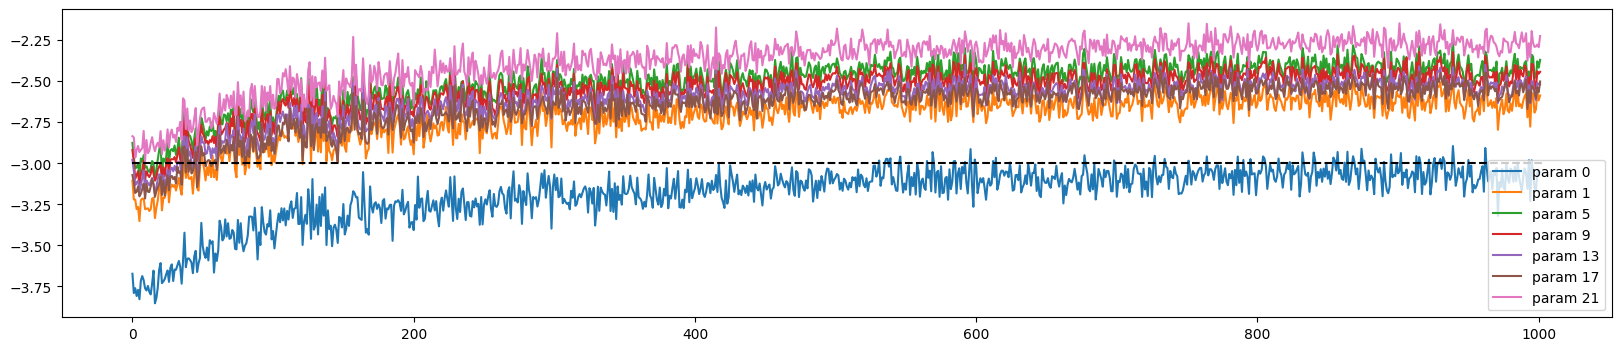

In [124]:
plt.figure(figsize=(20,4))
legends =[]
for i, p in enumerate(parameters):
    if p.ndim==2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k--')   # plot a horizontal line at 10^-3 to indicate the target update/data ratio
plt.legend(legends);

总结一下这个plus

第一，要学会BN方法，知道它的原理，知道它的用法

第二，把之前我们的代码用类似pytorch的格式模块化写一遍，像 Linear、 BatchNormld、 Tanh 这些，知道它们可以用来组装成神经网络。实际上我们写的代码和pytorch的api几乎完全一样

第三，我们介绍了一些诊断的方法，用来理解我们的神经网络是否是处于一个良好的状态。我们绘制了各类图像，包括正向传播和反向传播的历史图像、权重的更新图像等等各类数据，并通过这些图像来判断神经网络的情况。